In [39]:
import torch
from torch import nn
from torch import optim
from torchvision import datasets
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import ParameterGrid
from sklearn.model_selection import StratifiedKFold,KFold
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from CrossValidation import CrossValidation
from sklearn.datasets import load_iris
from torch.utils.data import TensorDataset, DataLoader
from sklearn import preprocessing
import AutoUtils

MNIST_FOLDER = "data"
inputData = "Iris"

In [40]:
DEVICE = None
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
    DEVICE = "cuda:0"
else:
    print("No GPU available. Training will run on CPU.")
    DEVICE = "cpu"

GPU: NVIDIA GeForce RTX 2080 SUPER is available.


In [41]:
# Transforms images to a PyTorch Tensor
tensor_transform = transforms.ToTensor()
 
if inputData == "MNIST":
    dataset = datasets.MNIST(root = MNIST_FOLDER,
                            train = True,
                            download = True,
                            transform = tensor_transform)
    

    test_dataset = datasets.MNIST(root = MNIST_FOLDER,
                            train = False,
                            download = True,
                            transform = tensor_transform)
else:
    iris = load_iris()
    dataset, test_dataset, dataset_target, test_target = train_test_split(
        iris.data, iris.target, test_size=0.2, random_state=42)
    scaler = preprocessing.StandardScaler().fit(dataset)
    dataset = scaler.transform(dataset) 
    test_dataset = scaler.transform(test_dataset) 
    dataset = TensorDataset(torch.tensor(dataset).float(), torch.tensor(dataset_target).float())
    # test_dataset = TensorDataset(torch.tensor(test_dataset).float(), torch.tensor(test_target).float())

In [42]:
def SimpleTrain(model, 
        optimizer,
        loss_function,
        train_loader,
        input_shape):
        acumulated_loss = 0
        model.train()
        num_batches = len(train_loader) 
        for (image, _) in train_loader:
                input_data = torch.flatten(image, start_dim=1).to(DEVICE) 
                # Consume input
                model_output = model(input_data)
                loss = loss_function(model_output, input_data)
                # Update weights
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                acumulated_loss += loss.item()
        avg_loss = acumulated_loss / num_batches
        return avg_loss, model

In [43]:
def SimpleValidation(model, 
        optimizer,
        loss_function,
        validation_loader,
        input_shape):
        model.eval()
        valid_loss = 0
        num_batches = len(validation_loader)
        with torch.no_grad():  # Disable gradient computation
                for (image, _)  in validation_loader:
                        input_data = torch.flatten(image, start_dim=1).to(DEVICE) 
                        model_output = model(input_data)
                        loss = loss_function(model_output, input_data)
                        valid_loss += loss.item()
                avg_valid_loss = valid_loss / num_batches 
        return avg_valid_loss

In [44]:
import SimpleAutoencoder as sae

if (inputData == "MNIST"):
    input_shape = 28 * 28
else:
    input_shape = 4

param_grid = ParameterGrid(
    {
        'epoch': [1000],
        'lr': [1e-3]
    })

results = {
    "train_loss": list(),
    "validation_loss": list(),
    "epoch": list(),
    "fold": list()}
best_model_flag = 9e99
best_model = None

for model_configuration in param_grid:
    epoch = model_configuration["epoch"]
    lr = model_configuration["lr"]
    print(f"{epoch = }\t{lr = }")
    cv = CrossValidation(5)
    for fold_index, dataloaders in enumerate(cv.GetSplitDataloader(dataset)):
        train_loader, validation_loader = dataloaders
        # Model
        model = sae.LinearAutoencoder(input_shape).to(DEVICE)
        loss_function = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(),
                                lr = lr)
        print(f"{fold_index = }")
        for n_epoch in tqdm(range(epoch)):
            train_loss, model = SimpleTrain(model, optimizer, loss_function, train_loader,
                            input_shape)
            validation_loss = SimpleValidation(model, optimizer, loss_function, validation_loader,
                            input_shape)
            results["train_loss"].append(train_loss)
            results["validation_loss"].append(validation_loss)
            results["fold"].append(fold_index)
            if train_loss <= best_model_flag:
                best_model = model
                best_model_flag = train_loss

print(best_model)

epoch = 1000	lr = 0.001
fold_index = 0


  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:03<00:00, 274.91it/s]


fold_index = 1


100%|██████████| 1000/1000 [00:03<00:00, 270.49it/s]


...

fold_index = 3


100%|██████████| 1000/1000 [00:03<00:00, 268.14it/s]


fold_index = 4


100%|██████████| 1000/1000 [00:03<00:00, 263.67it/s]

LinearAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=4, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=4, bias=True)
  )
)


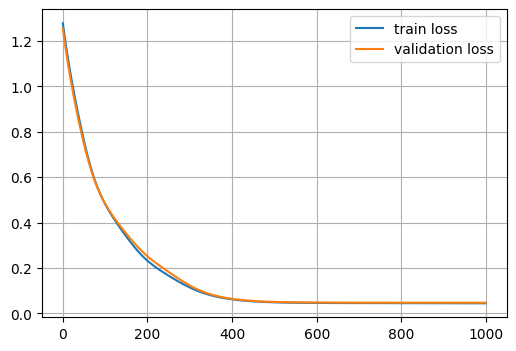

In [16]:
AutoUtils.PlotKKFoldLoss(results)

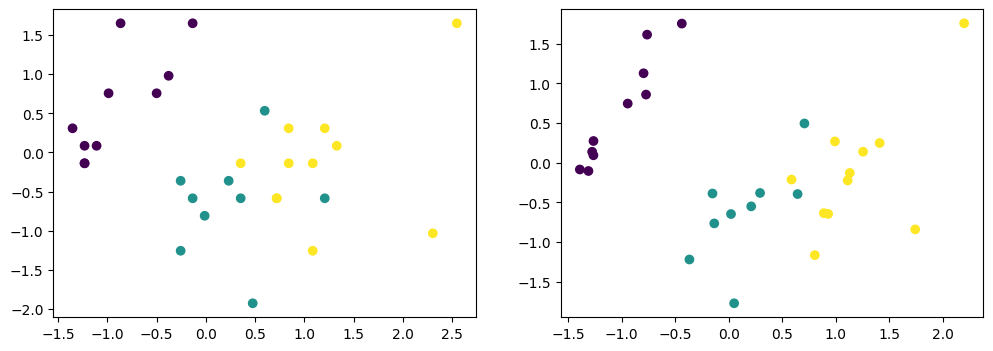

In [17]:
AutoUtils.PlotIris(test_dataset, test_target, best_model, DEVICE)

explained variance ratio (first two components): [0.79915698 0.16806219 0.0263294  0.00645143]


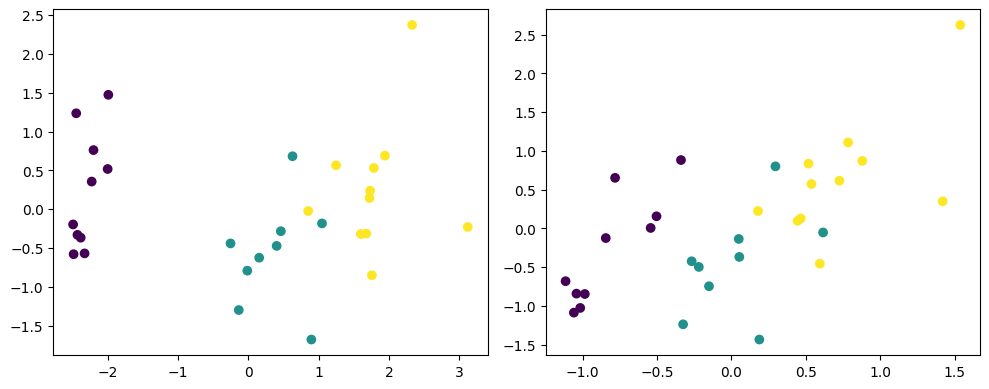

In [38]:
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

iris = datasets.load_iris()

X = test_dataset
y = test_target

pca = PCA(n_components=4)
X_r = pca.fit(X).transform(X)

# Percentage of variance explained for each components
print(
    "explained variance ratio (first two components): %s"
    % str(pca.explained_variance_ratio_)
)

fig, ax = plt.subplots(1,2, figsize=(10,4))
lw = 2

ax[0].scatter(X_r[:, 0], X_r[:, 1], c=test_target )

best_model.eval()
model_X = best_model(torch.tensor(X_r).float().to(DEVICE))
ax[1].scatter(
    model_X[:, 0].cpu().detach().numpy(),
    model_X[:, 1].cpu().detach().numpy(), c=test_target)


plt.tight_layout()
plt.show()